In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR=Path.cwd().parent.parent

DATA_PATH=(
    BASE_DIR
    /"data"
    /"raw"
    /"paysim.csv"
)

df=pd.read_csv(DATA_PATH)

In [3]:
df.shape

(6362620, 11)

In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [5]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

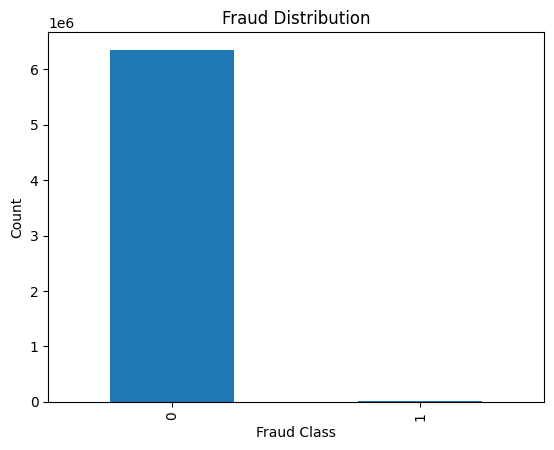

In [9]:
df["isFraud"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud Distribution")

plt.xlabel("Fraud Class")

plt.ylabel("Count")

plt.show()

In [10]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [11]:
fraud_by_type=df.groupby(
    "type"
)["isFraud"].sum()
fraud_by_type

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

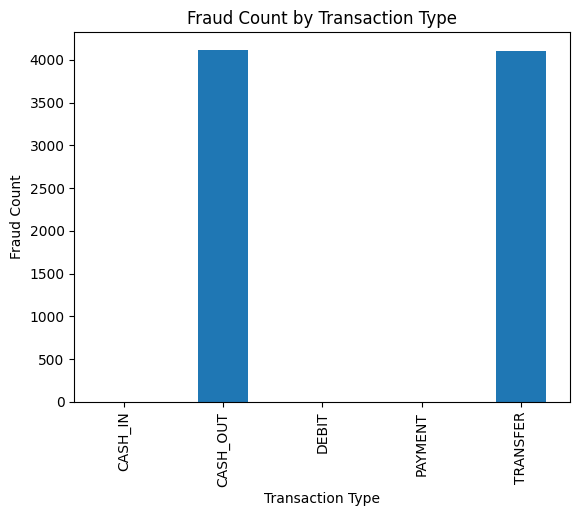

In [12]:
fraud_by_type.plot(kind="bar")

plt.title("Fraud Count by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Fraud Count")

plt.show()

In [13]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [14]:
df["origBalanceDiff"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
)

df["destBalanceDiff"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)

In [15]:
df["origBalanceDiff"].head()

0     9839.64
1     1864.28
2      181.00
3      181.00
4    11668.14
Name: origBalanceDiff, dtype: float64

In [16]:
df["destBalanceDiff"].head()

0        0.0
1        0.0
2        0.0
3   -21182.0
4        0.0
Name: destBalanceDiff, dtype: float64

In [17]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'origBalanceDiff', 'destBalanceDiff'],
      dtype='str')

In [18]:
numerical_df=df.select_dtypes(
    include=np.number
)

correlation=numerical_df.corr()["isFraud"]

correlation.sort_values(
    ascending=False
).head(15)

isFraud            1.000000
origBalanceDiff    0.362472
amount             0.076688
isFlaggedFraud     0.044109
step               0.031578
destBalanceDiff    0.027028
oldbalanceOrg      0.010154
newbalanceDest     0.000535
oldbalanceDest    -0.005885
newbalanceOrig    -0.008148
Name: isFraud, dtype: float64

In [19]:
df=df.drop(
    columns=["nameOrig","nameDest"]
)

In [20]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
       'origBalanceDiff', 'destBalanceDiff'],
      dtype='str')

In [21]:
fraud_amounts=df[df["isFraud"]==1]["amount"]

legit_amounts=df[df["isFraud"]==0]["amount"]

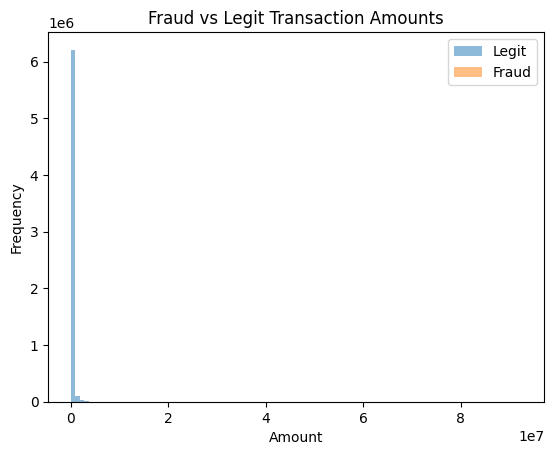

In [22]:
plt.hist(
    legit_amounts,
    bins=100,
    alpha=0.5,
    label="Legit"
)

plt.hist(
    fraud_amounts,
    bins=50,
    alpha=0.5,
    label="Fraud"
)

plt.legend()

plt.title("Fraud vs Legit Transaction Amounts")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

In [23]:
REPORT_DIR=Path.cwd().parent.parent/"reports"/"figures"
print(f"{REPORT_DIR}")

/home/afrozdebian/coding/fraud_detection/reports/figures


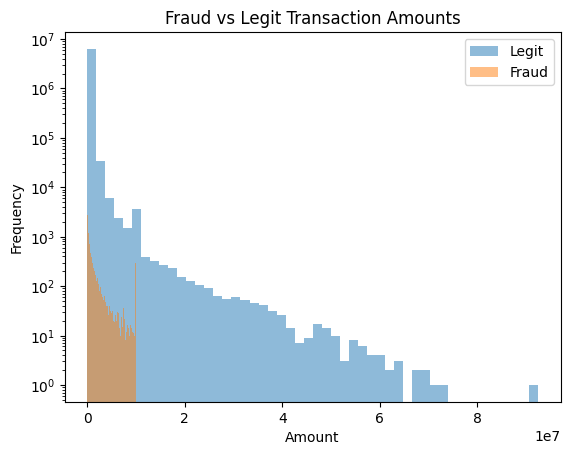

In [24]:
plt.hist(
    legit_amounts,
    bins=50,
    alpha=0.5,
    label="Legit"
)

plt.hist(
    fraud_amounts,
    bins=50,
    alpha=0.5,
    label="Fraud"
)

plt.title("Fraud vs Legit Transaction Amounts")

plt.xlabel("Amount")

plt.ylabel("Frequency")
plt.yscale("log")

plt.legend()

PLOT_DIR=REPORT_DIR/"fraud_vs_legit_transaction_amounts.png"


plt.savefig(
    PLOT_DIR
)
plt.show()



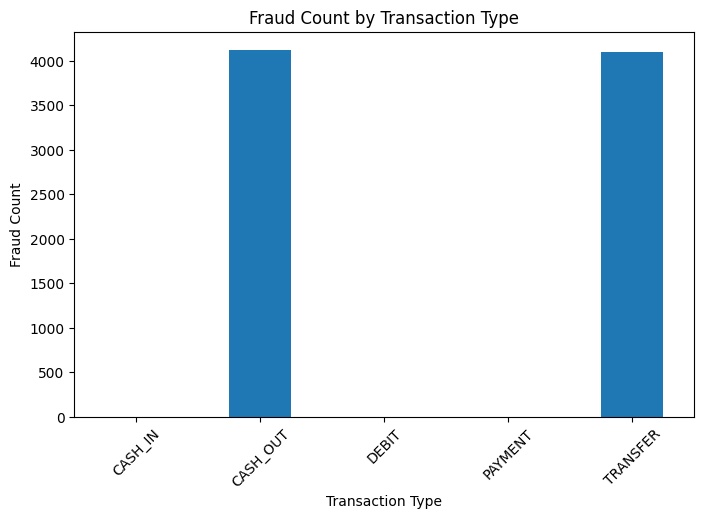

In [25]:
fraud_by_type = df.groupby("type")[
    "isFraud"
].sum()

plt.figure(figsize=(8,5))

fraud_by_type.plot(kind="bar")

plt.title("Fraud Count by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

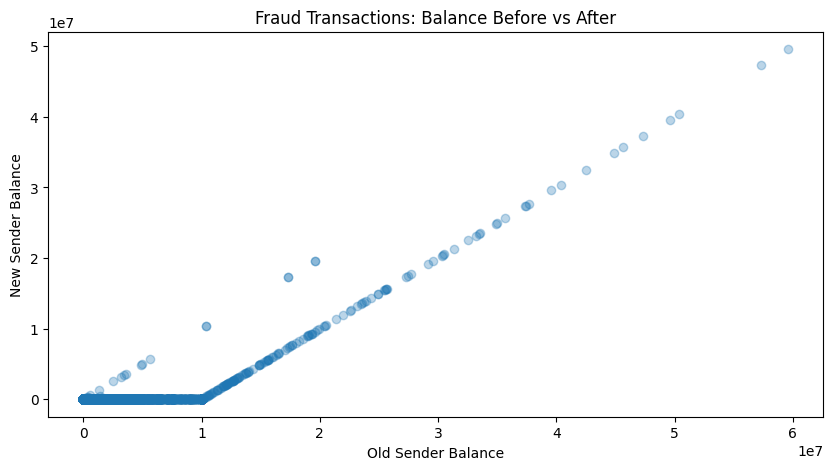

In [26]:
fraud_df = df[df["isFraud"] == 1]

plt.figure(figsize=(10,5))

plt.scatter(
    fraud_df["oldbalanceOrg"],
    fraud_df["newbalanceOrig"],
    alpha=0.3
)

plt.title(
    "Fraud Transactions: Balance Before vs After"
)

plt.xlabel("Old Sender Balance")

plt.ylabel("New Sender Balance")
PLOT_DIR=REPORT_DIR/"Fraud Transactions: Balance Before vs After.png"
plt.savefig(PLOT_DIR)
plt.show()

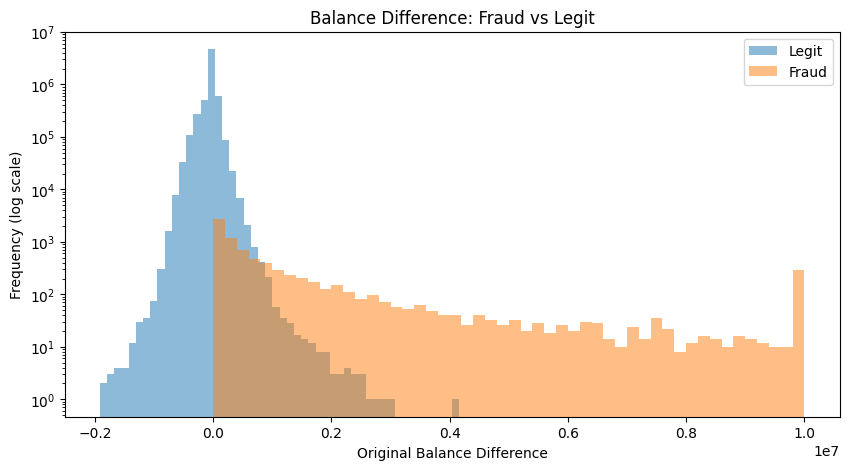

In [27]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df["isFraud"] == 0]["origBalanceDiff"],
    bins=50,
    alpha=0.5,
    label="Legit"
)

plt.hist(
    df[df["isFraud"] == 1]["origBalanceDiff"],
    bins=50,
    alpha=0.5,
    label="Fraud"
)

plt.yscale("log")

plt.title(
    "Balance Difference: Fraud vs Legit"
)

plt.xlabel("Original Balance Difference")

plt.ylabel("Frequency (log scale)")

plt.legend()
PLOT_DIR=REPORT_DIR/"Balance Difference: Fraud vs Legit"
plt.savefig(PLOT_DIR)
plt.show()

In [28]:
df = pd.read_csv(DATA_PATH)

In [29]:
df=df.drop(
    columns=["nameOrig", "nameDest"]
)

In [30]:
df["origBalanceDiff"]=(
    df["oldbalanceOrg"]
    -df["newbalanceOrig"]
)

In [31]:
df["destBalanceDiff"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)

In [32]:
df=pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

In [33]:
df=df.drop(
    columns=["isFlaggedFraud"]
)

In [34]:
X=df.drop("isFraud", axis=1)

y=df["isFraud"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
y_train.head()

292779     0
499763     0
2970411    0
3137549    0
1500682    0
Name: isFraud, dtype: int64

In [37]:
negative=y_train.value_counts()[0]

positive=y_train.value_counts()[1]

scale_pos_weight=negative/positive

print(scale_pos_weight)

773.7482496194825


In [38]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [39]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [40]:
y_pred=xgb_model.predict(X_test)

y_probs=xgb_model.predict_proba(X_test)[:,1]

In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test, y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.64      0.97      0.77      1643

    accuracy                           1.00   1272524
   macro avg       0.82      0.99      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



In [42]:
from sklearn.metrics import roc_auc_score

roc_auc=roc_auc_score(
    y_test,
    y_probs
)

print("ROC-AUC", roc_auc)

ROC-AUC 0.9996593271469816


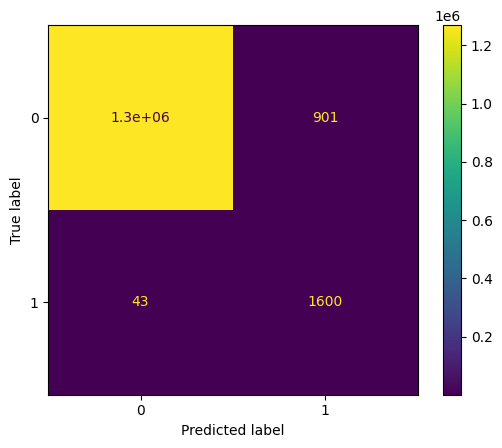

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [45]:
importance=pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
    
)

top_features=importance.sort_values(
    ascending=False
).head(10)

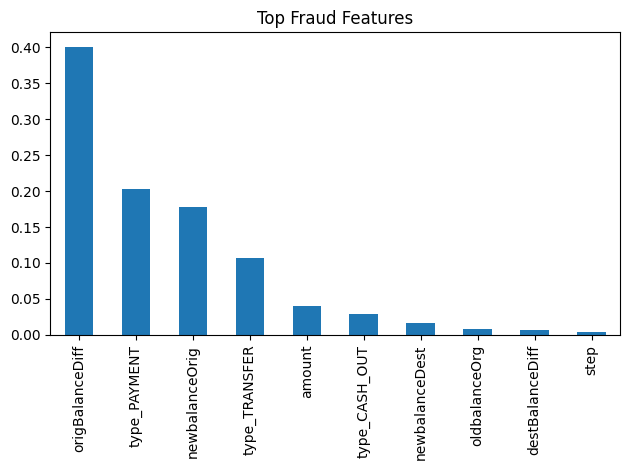

In [48]:
top_features.plot(kind="bar")

plt.title("Top Fraud Features")

plt.tight_layout()

PLOT_DIR=REPORT_DIR/"Top Fraud Features.png"

plt.savefig(PLOT_DIR)

plt.show()

In [49]:
from sklearn.metrics import classification_report

thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

for threshold in thresholds:

    y_pred_threshold = (
        y_probs > threshold
    ).astype(int)

    print(f"\nThreshold: {threshold}")

    print(
        classification_report(
            y_test,
            y_pred_threshold
        )
    )


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.43      0.99      0.60      1643

    accuracy                           1.00   1272524
   macro avg       0.72      0.99      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.51      0.98      0.67      1643

    accuracy                           1.00   1272524
   macro avg       0.75      0.99      0.84   1272524
weighted avg       1.00      1.00      1.00   1272524


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.56      0.98      0.71      1643

    accuracy                           1.00   1272524
   macro avg       0.78      0.99      0.86   1272524
weighted avg       1.00   